Original dimensions: 784 x 658

2x2 rotation matrix:
[[ 0.70710677  0.70710677]
 [-0.70710677  0.70710677]]

New dimensions: 1020 x 1020

2x3 affine rotation matrix:
[[ 7.07106781e-01 -7.07106781e-01  4.65452273e+02]
 [ 7.07106781e-01  7.07106781e-01  1.76010764e-01]]

Saved: task2_rotated_satellite.jpg


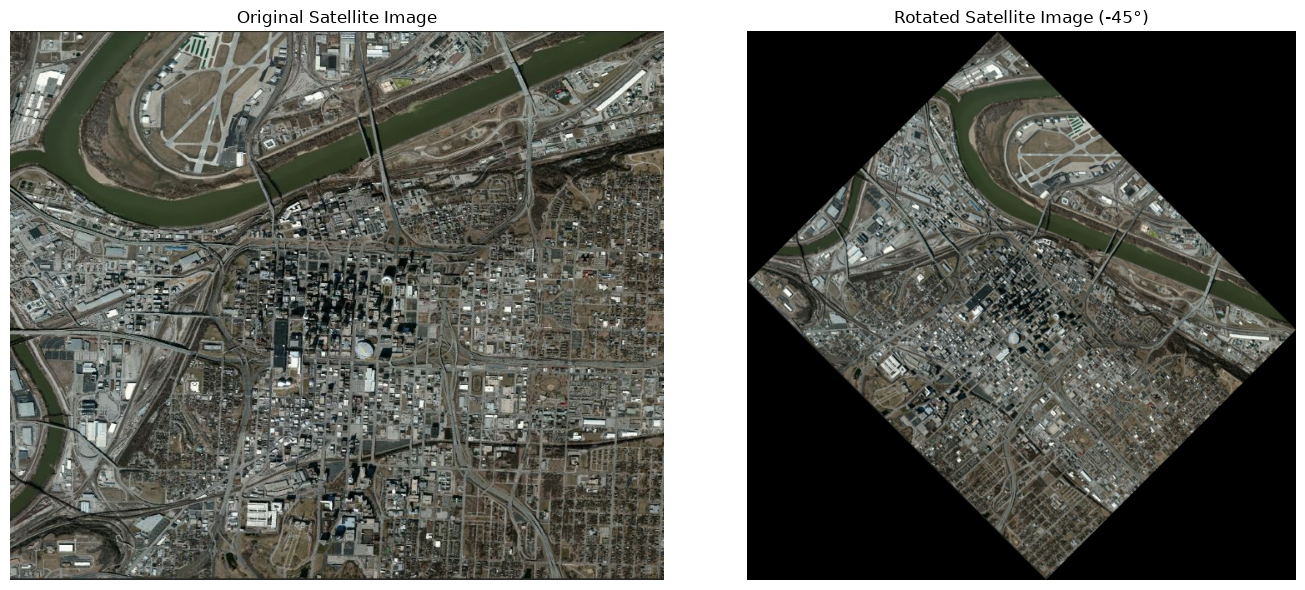

In [1]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "satellite.jpg"
output_path = "task2_rotated_satellite.jpg"

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Original dimensions:", w, "x", h)

# ---------------------------------------------------------
# Rotation angle
# ---------------------------------------------------------
theta_deg = -45.0
theta = math.radians(theta_deg)

# ---------------------------------------------------------
# Raw 2x2 rotation matrix
# ---------------------------------------------------------
R = np.array([
    [math.cos(theta), -math.sin(theta)],
    [math.sin(theta),  math.cos(theta)]
], dtype=np.float32)

print("\n2x2 rotation matrix:")
print(R)

# ---------------------------------------------------------
# Calculate new dimensions
# ---------------------------------------------------------
new_w = math.ceil(
    abs(w * math.cos(theta)) +
    abs(h * math.sin(theta))
)

new_h = math.ceil(
    abs(h * math.cos(theta)) +
    abs(w * math.sin(theta))
)

print("\nNew dimensions:", new_w, "x", new_h)

# ---------------------------------------------------------
# Create OpenCV rotation matrix
# ---------------------------------------------------------
M = cv2.getRotationMatrix2D(
    (w / 2.0, h / 2.0),
    theta_deg,
    1.0
)

# Shift image to centre of new canvas
M[0, 2] += (new_w - w) / 2.0
M[1, 2] += (new_h - h) / 2.0

print("\n2x3 affine rotation matrix:")
print(M)

# ---------------------------------------------------------
# Perform rotation
# ---------------------------------------------------------
result = cv2.warpAffine(
    img,
    M,
    (new_w, new_h),
    cv2.INTER_CUBIC
)

# ---------------------------------------------------------
# Save result
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Display original and rotated images in Jupyter
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Rotated Satellite Image (-45°)")
plt.axis("off")

plt.tight_layout()
plt.show()
